In [1]:
import pandas as pd
import numpy as np

# Task 0
Data extraction: get the data from 3 tables & combine it into single `.csv` file.
After that read this file using pandas to create Dataframe.
So it will be all joined data in 1 dataframe. Quick check - should be 74818 rows in it.

In [2]:
import sqlite3
conn = sqlite3.connect("../db.sqlite3")
cursor = conn.cursor()

In [7]:
cursor.execute(
    "select name, price, quantity, datetime "
    "from restaurant_order as ro "
    "inner join restaurant_orderitem as roi "
    "on ro.id = roi.order_id "
    "inner join restaurant_product as rp "
    "on roi.product_id = rp.id "
)
result = cursor.fetchall()
result

[('Plain Papadum', 0.8, 2, '2019-08-03 20:25:00'),
 ('King Prawn Balti', 12.95, 1, '2019-08-03 20:25:00'),
 ('Garlic Naan', 2.95, 1, '2019-08-03 20:25:00'),
 ('Mushroom Rice', 3.95, 1, '2019-08-03 20:25:00'),
 ('Paneer Tikka Masala', 8.95, 1, '2019-08-03 20:25:00'),
 ('Mango Chutney', 0.5, 1, '2019-08-03 20:25:00'),
 ('Plain Naan', 2.6, 1, '2019-08-03 20:17:00'),
 ('Mushroom Rice', 3.95, 1, '2019-08-03 20:17:00'),
 ('Tandoori Chicken (1/4)', 4.95, 1, '2019-08-03 20:17:00'),
 ('Vindaloo - Lamb', 7.95, 1, '2019-08-03 20:17:00'),
 ('Chapati', 1.95, 1, '2019-08-03 20:17:00'),
 ('Lamb Tikka', 4.95, 1, '2019-08-03 20:17:00'),
 ('Saag Paneer', 5.95, 1, '2019-08-03 20:17:00'),
 ('Aloo Chaat', 4.95, 1, '2019-08-03 20:09:00'),
 ('Chicken Pakora', 5.95, 1, '2019-08-03 20:09:00'),
 ('Chicken Chilli Garlic', 9.95, 1, '2019-08-03 20:09:00'),
 ('Lamb Biryani', 9.95, 1, '2019-08-03 20:09:00'),
 ('Keema Naan', 2.95, 1, '2019-08-03 20:09:00'),
 ('Chicken Pakora', 5.95, 1, '2019-08-03 20:01:00'),
 ('Plai

In [9]:
import csv
with open("../orders.csv", "w") as f:
    writer = csv.writer(f)
    writer.writerow(["name", "price", "quantity", "datetime"])
    writer.writerows(result)

In [10]:
df = pd.read_csv("../orders.csv")

# Task 1
Get Top 10 most popular products in restaurant sold by Quantity.
Count how many times each product was sold and create a pie chart with percentage of popularity (by quantity) for top 10 of them.

Example:

![pie chart](../demo/pie.png)

<Axes: title={'center': 'Top 10 positions in menu by quantity'}, ylabel='quantity'>

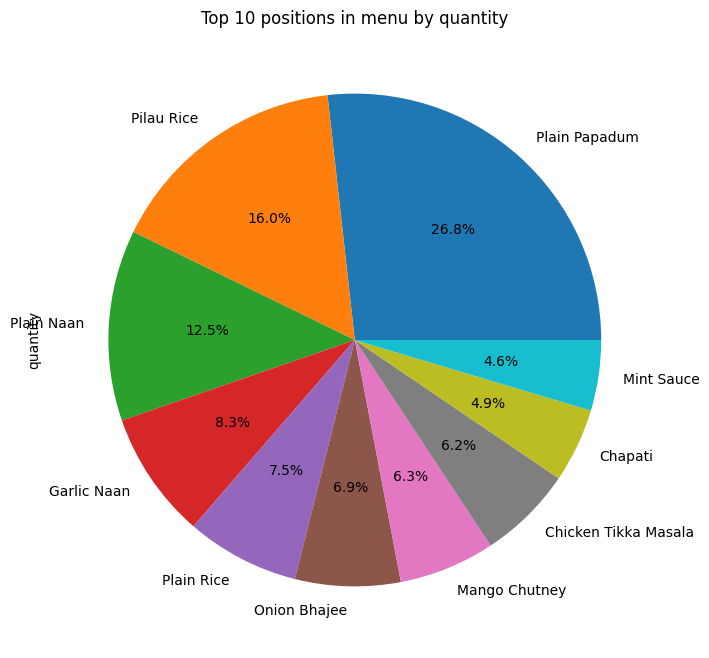

In [25]:
top_10_by_quantity = df.groupby("name")["quantity"].sum().sort_values(ascending=False).head(10)
top_10_by_quantity.plot.pie(autopct="%1.1f%%", figsize=(10, 8), title="Top 10 positions in menu by quantity")

# Task 2
Calculate `Item Price` (Product Price * Quantity) for each Order Item in dataframe.
And Make the same Top 10 pie chart, but this time by `Item Price`. So this chart should describe not the most popular products by quantity, but which products (top 10) make the most money for restaurant. It should be also with percentage.

In [28]:
df["item price"] = df["price"] * df["quantity"]

<Axes: title={'center': 'Top 10 positions in menu by item price'}, ylabel='item price'>

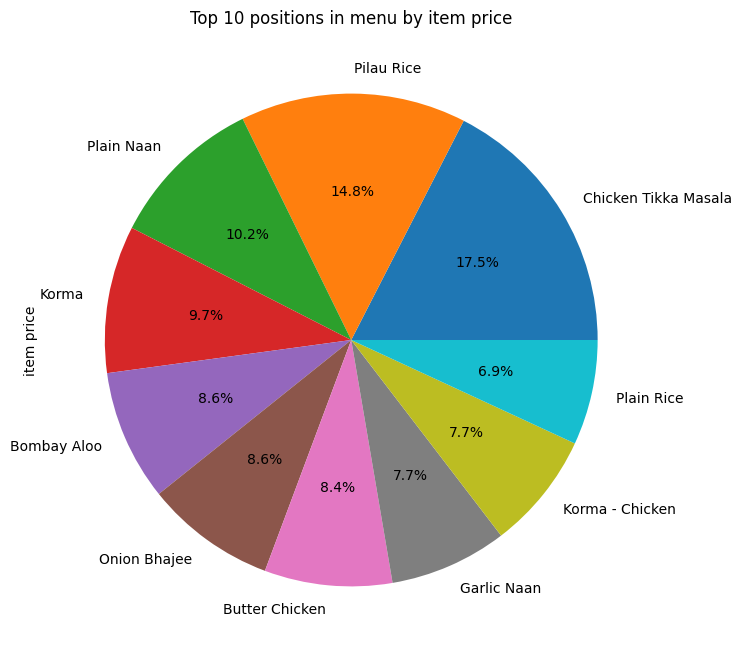

In [34]:
top_10_by_item_price = df.groupby("name")["item price"].sum().sort_values(ascending=False).head(10)
top_10_by_item_price.plot.pie(autopct="%1.1f%%", figsize=(10, 8), title="Top 10 positions in menu by item price")

# Task 3
Calculate `Order Hour` based on `Order Datetime`, which will tell about the specific our the order was created (from 0 to 23). Using `Order Hour` create a bar chart, which will tell the total restaurant income based on the hour order was created. So on x-axis - it will be values from 0 to 23 (hours), on y-axis - it will be the total sum of order prices, which were sold on that hour.

Example:

![bar chart](../demo/bar.png)

In [39]:
df["order_hour"] = pd.to_datetime(df["datetime"]).dt.hour

<Axes: title={'center': 'Profit by Order Hour'}, xlabel='order hour'>

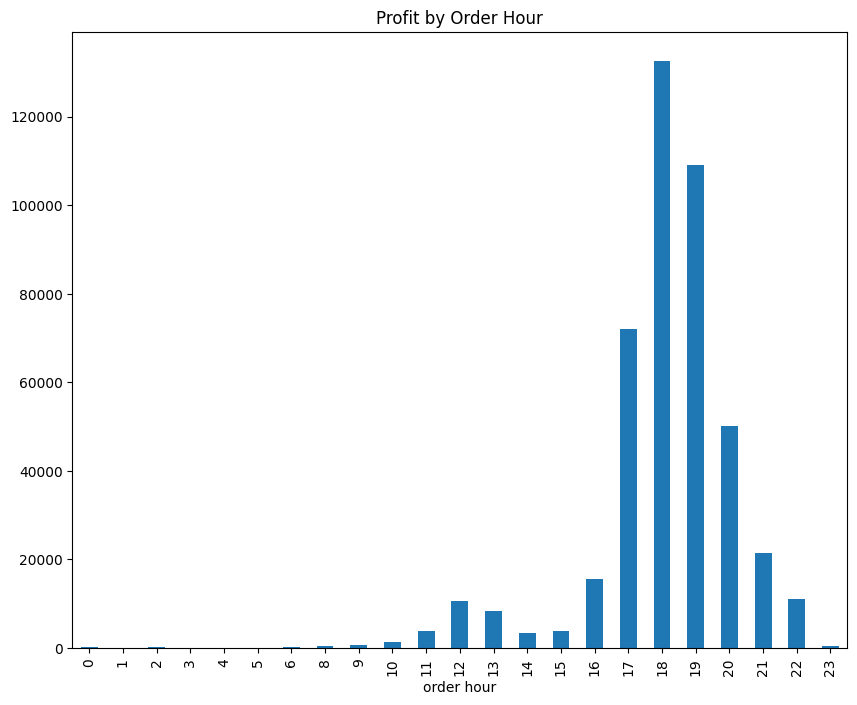

In [46]:
df.groupby("order hour")["item price"].sum().plot.bar(figsize=(10, 8), title="Profit by Order Hour")

# Task 4
Make similar bar chart, but right now with `Order Day Of The Week` (from Monday to Sunday), and also analyze total restaurant income by each day of the week.

<Axes: title={'center': 'Profit by Day of The Week'}, xlabel='Day of The Week'>

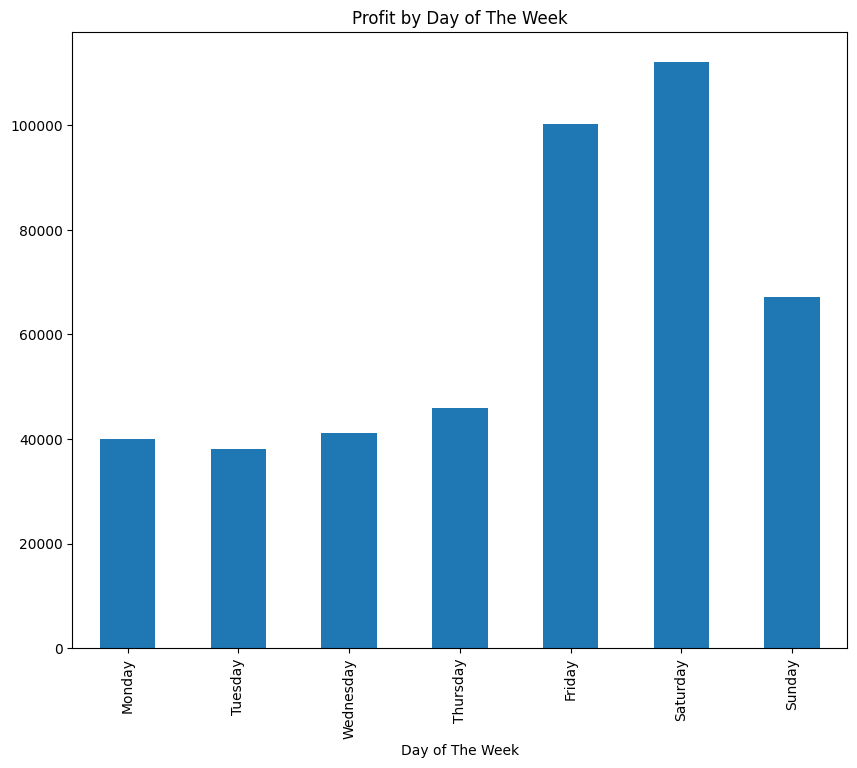

In [59]:
days = {0: "Monday", 1: "Tuesday", 2: "Wednesday", 3: "Thursday", 4: "Friday", 5: "Saturday", 6: "Sunday"}
df.groupby(pd.to_datetime(df["datetime"]).dt.dayofweek.map(days))["item price"].sum().reindex(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]).plot.bar(xlabel="Day of The Week", figsize=(10, 8), title="Profit by Day of The Week")